# Project Title

# UNDERSTANDING ACCIDENTS PATTERNS

## Goals

My project aims to find the lowest risk aircraft carriers and enhance aviation safety by understanding 
patterns in aviation accidents.

## Project overview
In this project using NTSB Aviation data(1962- 2023), the aim is to enhance aviation safety by understanding accident patterns and provide actionable insight for future investment opportunities. The data will be first reviewed to farmiliarise with the rows and columns.Then it will be checked for missing values and all unecessary datasets cleared. Finally we will perfom analysis with visualizations and provide recommendations and insights.

## Objectives

My objectives involve identifying recurring factors that contribute to incidents, such as specific aircraft types and weather conditions with aim to reduce accident frequency. Specific objectives include:
 1. Identifying which aircraft models or Makes are most associated with accidents and fatalities.
 2. Detecting long-term trends in accident rates to assess whether safety measures are effective over time or if new risks are emerging.
 3. Identify potential investments for stakeholders in aircraft Makes and airlines with low accident rates which will also help in long-term improvements on fleet management.

## Data

### Import python libraries and read the csv file to the notebook.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline


In [4]:
df = pd.read_csv('AviationData.csv', encoding='ISO-8859-1', low_memory=False)
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [5]:
df.tail(10) #To see the last 10 rows of the data

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
88879,20221219106472,Accident,DCA23LA096,2022-12-18,"Kahului, HI",United States,NaN,NaN,NaN,NaN,...,NaN,HAWAIIAN AIRLINES INC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88880,20221219106477,Accident,WPR23LA071,2022-12-18,"San Manual, AZ",United States,NaN,NaN,NaN,NaN,...,Personal,Chandler Air Service,0.0,0.0,0.0,3.0,NaN,NaN,NaN,20-12-2022
88881,20221221106483,Accident,CEN23LA067,2022-12-21,"Auburn Hills, MI",United States,NaN,NaN,NaN,NaN,...,Personal,Pilot,0.0,1.0,0.0,0.0,NaN,NaN,NaN,22-12-2022
88882,20221222106486,Accident,CEN23LA068,2022-12-21,"Reserve, LA",United States,NaN,NaN,NaN,NaN,...,Instructional,NaN,0.0,1.0,0.0,1.0,NaN,NaN,NaN,27-12-2022
88883,20221228106502,Accident,GAA23WA046,2022-12-22,"Brasnorte,",Brazil,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,0.0,0.0,0.0,NaN,NaN,NaN,28-12-2022
88884,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022
88885,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88886,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
88887,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88888,20221230106513,Accident,ERA23LA097,2022-12-29,"Athens, GA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,1.0,NaN,NaN,NaN,30-12-2022


In [6]:
df.describe() #To get the summary of the data.

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
count,82805.000000,77488.000000,76379.000000,76956.000000,82977.000000
mean,1.146585,0.647855,0.279881,0.357061,5.325440
std,0.446510,5.485960,1.544084,2.235625,27.913634
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000
max,8.000000,349.000000,161.000000,380.000000,699.000000


In [7]:
df.info()  # To get the data types of each column and the number of non-null values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

In [8]:
df.shape #To get the number of rows and columns in the data.

(88889, 31)

## Methods

 ### Data cleaning. First checking for null values.

In [9]:
df.isnull()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,False,False,False,False,False,False,True,True,True,True,...,False,True,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,True,True,True,True,...,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,True,...,False,True,False,True,True,True,False,False,False,False
3,False,False,False,False,False,False,True,True,True,True,...,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,True,True,True,...,False,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88884,False,False,False,False,False,False,True,True,True,True,...,False,True,False,False,False,False,True,True,True,False
88885,False,False,False,False,False,False,True,True,True,True,...,True,True,False,False,False,False,True,True,True,True
88886,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
88887,False,False,False,False,False,False,True,True,True,True,...,False,False,False,False,False,False,True,True,True,True


In [10]:
df.isnull().sum().sum()

565032

In [11]:
df.isnull().sum()

Event.Id                      0
Investigation.Type            0
Accident.Number               0
Event.Date                    0
Location                     52
Country                     226
Latitude                  54507
Longitude                 54516
Airport.Code              38757
Airport.Name              36185
Injury.Severity            1000
Aircraft.damage            3194
Aircraft.Category         56602
Registration.Number        1382
Make                         63
Model                        92
Amateur.Built               102
Number.of.Engines          6084
Engine.Type                7096
FAR.Description           56866
Schedule                  76307
Purpose.of.flight          6192
Air.carrier               72241
Total.Fatal.Injuries      11401
Total.Serious.Injuries    12510
Total.Minor.Injuries      11933
Total.Uninjured            5912
Weather.Condition          4492
Broad.phase.of.flight     27165
Report.Status              6384
Publication.Date          13771
dtype: i

### Make the null values in the continous data '0' instead of dropping the row.

In [12]:
df['Total.Fatal.Injuries'] = pd.to_numeric(df['Total.Fatal.Injuries'], errors='coerce').fillna(0).astype(int)

In [13]:
df.isnull().sum()

Event.Id                      0
Investigation.Type            0
Accident.Number               0
Event.Date                    0
Location                     52
Country                     226
Latitude                  54507
Longitude                 54516
Airport.Code              38757
Airport.Name              36185
Injury.Severity            1000
Aircraft.damage            3194
Aircraft.Category         56602
Registration.Number        1382
Make                         63
Model                        92
Amateur.Built               102
Number.of.Engines          6084
Engine.Type                7096
FAR.Description           56866
Schedule                  76307
Purpose.of.flight          6192
Air.carrier               72241
Total.Fatal.Injuries          0
Total.Serious.Injuries    12510
Total.Minor.Injuries      11933
Total.Uninjured            5912
Weather.Condition          4492
Broad.phase.of.flight     27165
Report.Status              6384
Publication.Date          13771
dtype: i

In [14]:
for col in ['Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

In [15]:
df.isnull().sum()

Event.Id                      0
Investigation.Type            0
Accident.Number               0
Event.Date                    0
Location                     52
Country                     226
Latitude                  54507
Longitude                 54516
Airport.Code              38757
Airport.Name              36185
Injury.Severity            1000
Aircraft.damage            3194
Aircraft.Category         56602
Registration.Number        1382
Make                         63
Model                        92
Amateur.Built               102
Number.of.Engines          6084
Engine.Type                7096
FAR.Description           56866
Schedule                  76307
Purpose.of.flight          6192
Air.carrier               72241
Total.Fatal.Injuries          0
Total.Serious.Injuries        0
Total.Minor.Injuries          0
Total.Uninjured               0
Weather.Condition          4492
Broad.phase.of.flight     27165
Report.Status              6384
Publication.Date          13771
dtype: i

In [16]:
df.describe()

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
count,82805.000000,88889.000000,88889.000000,88889.000000,88889.000000
mean,1.146585,0.564761,0.240491,0.309127,4.971245
std,0.446510,5.126649,1.434614,2.083715,27.002011
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000
max,8.000000,349.000000,161.000000,380.000000,699.000000


### Check for duplicates in the code.

In [17]:
duplicates = df[df.duplicated()]
print(len(duplicates))
duplicates.head()

0


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

### Viewing the columns in the dataset

In [19]:
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

### Dropping null values under Event.Date rows.

In [20]:
df.dropna(subset = ['Event.Date'])

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2,0,0,0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4,0,0,0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3,0,0,0,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2,0,0,0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1,2,0,0,VMC,Approach,Probable Cause,16-04-1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88884,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0,1,0,0,NaN,NaN,NaN,29-12-2022
88885,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN
88886,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0,0,0,1,VMC,NaN,NaN,27-12-2022
88887,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0,0,0,0,NaN,NaN,NaN,NaN


### Change Event.Date to datetime object

In [21]:
df['Event.Date'] = pd.to_datetime(df['Event.Date'])

In [22]:
df['Event.Date'].head()

0   1948-10-24
1   1962-07-19
2   1974-08-30
3   1977-06-19
4   1979-08-02
Name: Event.Date, dtype: datetime64[ns]

In [23]:
df['Event.Date'].describe()

count                            88889
mean     1999-09-17 17:13:39.354475904
min                1948-10-24 00:00:00
25%                1989-01-15 00:00:00
50%                1998-07-18 00:00:00
75%                2009-07-01 00:00:00
max                2022-12-29 00:00:00
Name: Event.Date, dtype: object

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Event.Id                88889 non-null  object        
 1   Investigation.Type      88889 non-null  object        
 2   Accident.Number         88889 non-null  object        
 3   Event.Date              88889 non-null  datetime64[ns]
 4   Location                88889 non-null  object        
 5   Country                 88889 non-null  object        
 6   Latitude                34382 non-null  object        
 7   Longitude               34373 non-null  object        
 8   Airport.Code            50132 non-null  object        
 9   Airport.Name            52704 non-null  object        
 10  Injury.Severity         88889 non-null  object        
 11  Aircraft.damage         88889 non-null  object        
 12  Aircraft.Category       32287 non-null  object

### Fill the categorical data with Unknown intead of Nan

In [26]:
categorical_cols = ['Location', 'Country', 'Injury.Severity', 'Aircraft.damage', 'Make', 'Model', 
                    'Weather.Condition', 'Broad.phase.of.flight']
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

### Dropping the columns and remaining with the cleaned data. Making a copy of the data by storing new data in new variable.

In [27]:
df2 = df.dropna(axis = 1)
df2.head(10)

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Make,Model,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,Fatal(2),Destroyed,Stinson,108-3,2,0,0,0,UNK,Cruise
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,Fatal(4),Destroyed,Piper,PA24-180,4,0,0,0,UNK,Unknown
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,Fatal(3),Destroyed,Cessna,172M,3,0,0,0,IMC,Cruise
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,Fatal(2),Destroyed,Rockwell,112,2,0,0,0,IMC,Cruise
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,Fatal(1),Destroyed,Cessna,501,1,2,0,0,VMC,Approach
5,20170710X52551,Accident,NYC79AA106,1979-09-17,"BOSTON, MA",United States,Non-Fatal,Substantial,Mcdonnell Douglas,DC9,0,0,1,44,VMC,Climb
6,20001218X45446,Accident,CHI81LA106,1981-08-01,"COTTON, MN",United States,Fatal(4),Destroyed,Cessna,180,4,0,0,0,IMC,Unknown
7,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,Non-Fatal,Substantial,Cessna,140,0,0,0,2,VMC,Takeoff
8,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,Non-Fatal,Substantial,Cessna,401B,0,0,0,2,IMC,Landing
9,20020909X01560,Accident,MIA82DA029,1982-01-01,"JACKSONVILLE, FL",United States,Non-Fatal,Substantial,North American,NAVION L-17B,0,0,3,0,IMC,Cruise


In [28]:
df2['Make'].value_counts().head(5)

Make
Cessna    22227
Piper     12029
CESSNA     4922
Beech      4330
PIPER      2841
Name: count, dtype: int64

### Creating a second csv document with the cleaned data to assist in visualization. Named it 'cleaned_aviation_data.csv'.

In [29]:
df2.to_csv('cleaned_aviation_data.csv', index=False)
df2.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Make,Model,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,Fatal(2),Destroyed,Stinson,108-3,2,0,0,0,UNK,Cruise
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,Fatal(4),Destroyed,Piper,PA24-180,4,0,0,0,UNK,Unknown
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,Fatal(3),Destroyed,Cessna,172M,3,0,0,0,IMC,Cruise
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,Fatal(2),Destroyed,Rockwell,112,2,0,0,0,IMC,Cruise
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,Fatal(1),Destroyed,Cessna,501,1,2,0,0,VMC,Approach


In [30]:
df2.loc[:, 'Injury.Severity'] = df2['Injury.Severity'].str.replace(r'\(.*\)', '', regex=True).str.strip()
df2['Injury.Severity'].head()

0    Fatal
1    Fatal
2    Fatal
3    Fatal
4    Fatal
Name: Injury.Severity, dtype: object

# VISUALIZATION

# 1. Bar Chart: Accidents by Aircraft Make
Purpose: Identifies which aircraft Make are most frequently involved in accidents, useful for manufacturers, regulators and potential investors.


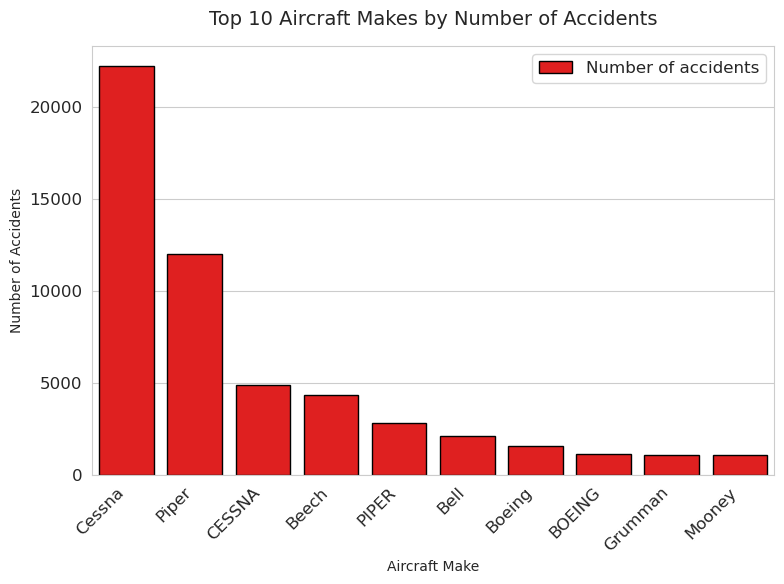

In [47]:

plt.figure(figsize=(8, 6))
top_makes = df2['Make'].value_counts().head(10)

sns.barplot(x=top_makes.index, y=top_makes.values, edgecolor ='black', color ='red',label='Number of accidents')
plt.title('Top 10 Aircraft Makes by Number of Accidents', fontsize=14, pad=15)
plt.xlabel('Aircraft Make', fontsize=10)
plt.ylabel('Number of Accidents', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('accidents_by_make.png', dpi=300)
plt.show()

According to the above bar chart we see that Cessna has the highest number of accidents. This shows that the Make of Cessna is a high risk investment and a safety concern.

# 2. Line Chart: Accidents Over Time
Purpose: Shows trends in accident frequency over years, useful for long-term safety planning. We extracts the year from Event.Date, counts accidents per year and plot on a lineplot.

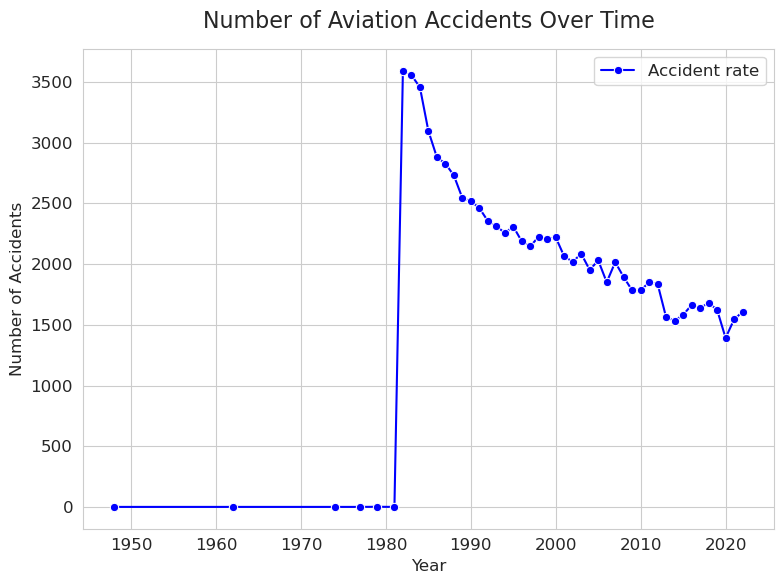

In [33]:
plt.figure(figsize=(8, 6))
df['Year'] = df2['Event.Date'].dt.year
accidents_by_year = df['Year'].value_counts().sort_index()
sns.lineplot(x=accidents_by_year.index, y=accidents_by_year.values, marker='o', color='b', label='Accident rate')
plt.title('Number of Aviation Accidents Over Time', fontsize=16, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.tight_layout()
plt.savefig('accidents_over_time.png', dpi=300)
plt.show()

According to the lineplot, we can see the most number of accidents were around 1982 and have modirately reduces. This could be due to improved safety measures and procedures over the years.Point to note as well is that it is better to buy a newer aircraft carrier model which are up to date and well maintained.

# 3. A histogram and line graph: injury severities across diferrent aircraft makes

Purpose: To show how fatal are in relation to which aircraft and connect specific aircraft to severity outcome.If "Fatal" has the tallest bar, it suggests severe outcomes are common among these makes, prompting deeper investigation.

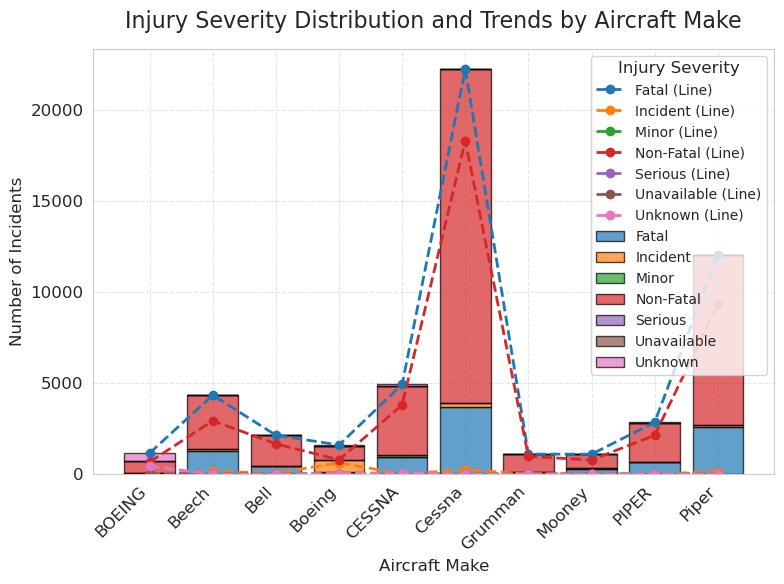

In [46]:
plt.figure(figsize=(8, 6))

# Filter to top 10 makes and create a copy
top_makes = df2['Make'].value_counts().head(10).index

# Prepare data: Count incidents per Make and Injury.Severity
severity_by_make = df2.groupby(['Make', 'Injury.Severity']).size().unstack(fill_value=0)
severities = severity_by_make.columns  # e.g., ['Fatal', 'Minor', 'Serious', 'Unknown']

# Histogram: Stacked bars for each Make
bottom = None
for severity in severities:
    plt.bar(
        severity_by_make.index,
        severity_by_make[severity],
        bottom=bottom,
        label=severity,
        edgecolor='black',
        alpha=0.7  # Slight transparency for overlap
    )
    # Update bottom for stacking
    if bottom is None:
        bottom = severity_by_make[severity]
    else:
        bottom += severity_by_make[severity]
# Line Graph: Overlay lines for each severity
for severity in severities:
    plt.plot(
        severity_by_make.index,
        severity_by_make[severity],
        marker='o',
        linestyle='--',
        linewidth=2,
        label=f'{severity} (Line)' if severity in plt.gca().get_legend_handles_labels()[1] else severity
    )


# Customize
plt.title('Injury Severity Distribution and Trends by Aircraft Make', fontsize=16, pad=15)
plt.xlabel('Aircraft Make', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Injury Severity', title_fontsize=12, fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()


# Save and show
plt.savefig('injury_severity_combined_by_make.png', dpi=300)
plt.show()

The stacked histogram bars show the total count of incidents per Make, with colors indicating Injury.Severity proportions 
e.g., Cessna’s bar might be mostly red for Fatal incidents.Line graph trace individual severity counts across makes, highlighting trends 
e.g. , Fatal incidents peaking at Cessna, dipping at Boeing, and rising again at Piper. This further supports the above histogram conclusion that 
Boeing, Grumman and Mooney are the low risk investments aircraft Make.

# 4.Pie chart: Fatal injuries by weather conditions.

The purpose of the pie chart is to identifies high-risk weather conditions aiding investors and safety regulators in targeting weather-related safety measures.

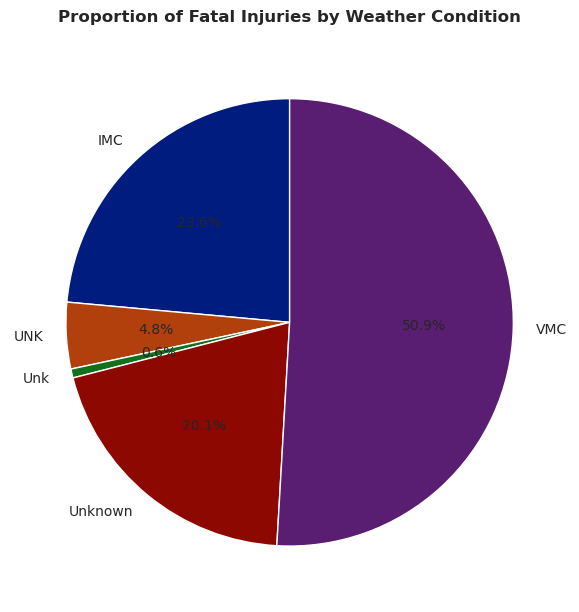

In [48]:
plt.figure(figsize=(6, 8))
fatal_by_weather = df.groupby('Weather.Condition')['Total.Fatal.Injuries'].sum()
# Filter out 'UNKNOWN' or low-value categories for clarity (optional)
fatal_by_weather = fatal_by_weather[fatal_by_weather > 0] 
plt.pie(fatal_by_weather, labels=fatal_by_weather.index, 
        colors=sns.color_palette('dark'), startangle=90, textprops={'fontsize': 10}, labeldistance=1.1, autopct='%1.1f%%')
plt.title('Proportion of Fatal Injuries by Weather Condition', fontsize=12, pad=15, weight='bold')
plt.tight_layout()
plt.savefig('fatality_by_weather.png', dpi=150)
plt.show()

The above pie chart shows that the VMC weather condition shows the highest fatility injury rate.
This might be due to visiblity related issues.During the VMC weather condition better weather safety protocols should be implemented
and there is also need for enhanced radar tools. 

## Conclusion

The above analysis is based on the AviationData.csv file. The data was cleaned and analyzed to get insights into the aviation accidents.
The data was cleaned by handling missing values, converting data types, and removing duplicates. The analysis included visualizations 
to show the distribution of accidents by aircraft make, accidents over time, injury severity by aircraft make, and fatal injuries by
weather condition. The visualizations provide a clear understanding of the data and help in identifying patterns and trends in aviation
accidents. 

### Business Recommendation 1

The head of the new aviation division should analyze the injury severity distribution by aircraft make to prioritize safety improvements in the aircrafts to minimize operational errors. This will market the company as the "safest new operator" improving business and making it easier to target high-end clients.

### Business Recommendation 2

The new aviation division should target no fatal accident aircrafts which are mordern and upto date with advanced weather radar and autopilot systems. Aircrafts like the Boeing looks like a good place to start.

### Business Recommendation 3

The safety board should focus on the top aircraft makes with highest number of accidents to improve safety measures and reduce incidents. They can also monitor the trend of aviation accidents over time to identify potential risk factors and take preventive actions.